<a href="https://colab.research.google.com/github/baubyte/CienciaDeDatos/blob/main/Semana_5/1_practica_series_temporales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Práctica: Series temporales con pandas
### Turismo internacional en Argentina (2016–2024)

**Fuente:** Encuesta de Turismo Internacional (ETI) — INDEC / Ministerio de Turismo y Deportes  
**Datos:** turistas no residentes que ingresaron a Argentina por Ezeiza y Aeroparque

---

En esta práctica vamos a trabajar con una serie temporal real. El objetivo es aplicar las tres herramientas centrales de pandas para datos temporales:
- `pd.to_datetime()` y el `DatetimeIndex`
- `.resample()` para cambiar la frecuencia de la serie
- `.rolling()` para calcular estadísticas sobre ventanas deslizantes

---

---

## Recordatorio conceptual rápido
---
### Datetime — Formato de fechas

Cuando pandas lee un archivo CSV, las fechas llegan como texto (`object`). Pandas no sabe que `"2024-01-01"` es una fecha — para él es simplemente una cadena de caracteres, igual que `"hola"`.

`pd.to_datetime()` convierte ese texto a un tipo de dato real de fecha (`datetime64`), que pandas sí entiende como tiempo.

### DatetimeIndex — el índice temporal de pandas

Para trabajar con series temporales, la columna de fechas tiene que ser el **índice** del DataFrame y tener tipo `DatetimeIndex`. Sin esto,  cambiar la frecuencia de la serie `resample()` y trabajar con media móvil simple `rolling()` no se puede.

```python
df['fecha'] = pd.to_datetime(df['fecha'])   # convertir texto a fecha
df = df.set_index('fecha')                  # establecer como índice
```

Una vez activado, se puede acceder a partes de la fecha desde el índice:

```python
df.index.year    # año
df.index.month   # mes (1 a 12)
df.loc['2022']   # todos los datos de 2022
df.loc['2020-03':'2021-06']  # rango de meses
```

---

### resample() — cambiar la frecuencia de la serie

Equivalente temporal de `groupby()`: agrupa las observaciones en períodos más largos y aplica una función de agregación *(aggregation function)*.
Cambia la frecuencia de la serie: de mensual a anual, trimestral, etc.

- resample(): El tiempo importa. Querés ver qué pasó en cada período.
EJ: "¿Cómo evolucionó el turismo mes a mes desde 2010 hasta hoy?" (Resultado: 1 fila por cada mes transcurrido)

- groupby(): El tiempo no importa. Querés comparar posiciones dentro del año sumando todos los años.EJ: "¿Cuál es, históricamente, el mes con más turismo?" (Resultado: 12 filas).

```python
df.resample('YE').sum()    # total por año
df.resample('QE').mean()   # promedio por trimestre
df.resample('ME').count()  # cantidad de registros por mes
```

**Códigos de frecuencia más usados:** `'D'` diario · `'W'` semanal · `'ME'` mensual · `'QE'` trimestral · `'YE'` anual

> Diferencia clave con `groupby`: `resample` conserva el `DatetimeIndex` en el resultado. `groupby(df.index.year)` devuelve un índice numérico y pierde la naturaleza temporal.

---

### rolling() — media móvil simple *(Simple Moving Average, SMA)*

Calcula el promedio de los últimos N períodos para cada punto. **Mantiene la misma cantidad de filas** que la serie original — no colapsa los datos.No cambia la frecuencia — suaviza para hacer visible la tendencia.Todos los períodos pesan igual.

```python
df['ventas'].rolling(window=12).mean()   # promedio móvil de 12 meses
```

**Propiedades importantes:**
- Todos los N períodos tienen el **mismo peso** (1/N).
- Los primeros N−1 valores del resultado son `NaN` porque la ventana no está completa todavía.
- Tiene **rezago** *(lag)*: reacciona con demora a cambios recientes, proporcional a N/2 períodos.
- Ventana grande → más suavizado, más rezago. Ventana chica → menos suavizado, más reactiva.

**Regla práctica:** datos mensuales con `window=12` elimina la estacionalidad anual.

---

### ewm() — media móvil exponencial *(Exponentially Weighted Moving Average, EWMA)*

Similar a `rolling()` pero da **más peso a los datos recientes**. Reacciona más rápido a cambios y no genera `NaN` iniciales.

```python
df['ventas'].ewm(span=12).mean()   # EWMA equivalente a ventana de 12
```

| | SMA — `rolling()` | EWMA — `ewm()` |
|---|---|---|
| Pesos | Iguales (1/N) | Decrecientes (más peso a lo reciente) |
| Rezago *(lag)* | Sí, ~N/2 períodos | Menor, reacciona más rápido |
| NaN iniciales | Sí (primeros N−1) | No |

---

> **Para tener en cuenta:** `rolling()` y `ewm()` son herramientas de **suavizado y visualización**. No generan pronósticos ni intervalos de confianza. Para pronosticar valores futuros se usan modelos estadísticos completos como Holt-Winters, ARIMA/SARIMA o Prophet.

---


## Parte 1: Cargar y preparar los datos

### 1.1 Importar bibliotecas

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

### 1.2 Cargar el dataset

El archivo `turismo_internacional_argentina.csv` tiene dos columnas:
- `fecha`: primer día de cada mes en formato YYYY-MM-DD
- `turistas_no_residentes_miles`: cantidad de turistas no residentes (en miles)

In [2]:
df = pd.read_csv('turismo_internacional_argentina.csv')
df.head()

,fecha,turistas_no_residentes_miles
0,2016-01-01,456
1,2016-02-01,298
2,2016-03-01,221
3,2016-04-01,185
4,2016-05-01,152


In [3]:
# ¿Qué tipo de dato tiene la columna 'fecha'?
print(df.dtypes)

fecha                           object
turistas_no_residentes_miles     int64
dtype: object


### 1.3 Convertir la columna de fechas y establecerla como índice

Para que pandas reconozca la columna `fecha` como tiempo (y no como texto), necesitamos:
1. Convertirla con `pd.to_datetime()`
2. Establecerla como índice del DataFrame con `set_index()`

Esto activa el `DatetimeIndex`, que es lo que habilita `resample()` y `rolling()`.

In [4]:
df['fecha'] = pd.to_datetime(df['fecha'])
df = df.set_index('fecha')

# Verificar
print(type(df.index))
df.head()

<class 'pandas.core.indexes.datetimes.DatetimeIndex'>


,turistas_no_residentes_miles
fecha,
2016-01-01,456
2016-02-01,298
2016-03-01,221
2016-04-01,185
2016-05-01,152


### 1.4 Primer vistazo a la serie

Graficar la serie completa. ¿Qué patrones pueden observar a simple vista?

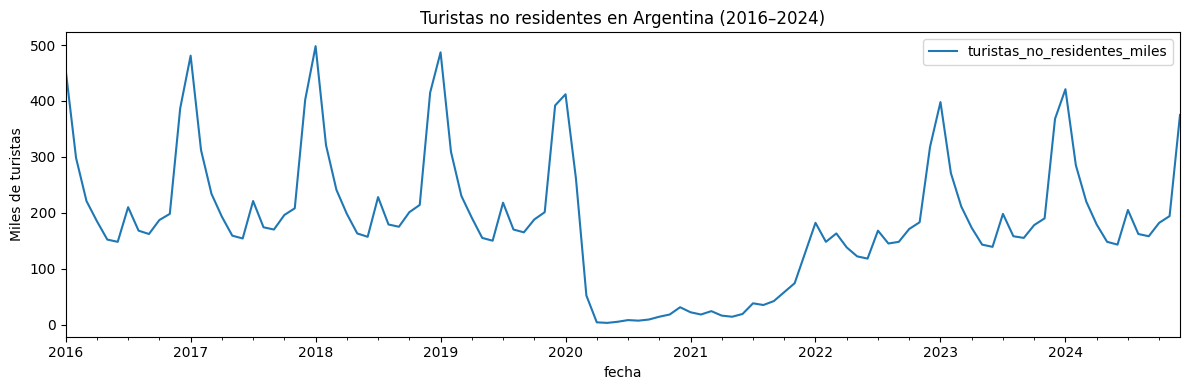

In [5]:
df.plot(figsize=(12, 4), title='Turistas no residentes en Argentina (2016–2024)', ylabel='Miles de turistas')
plt.tight_layout()
plt.show()

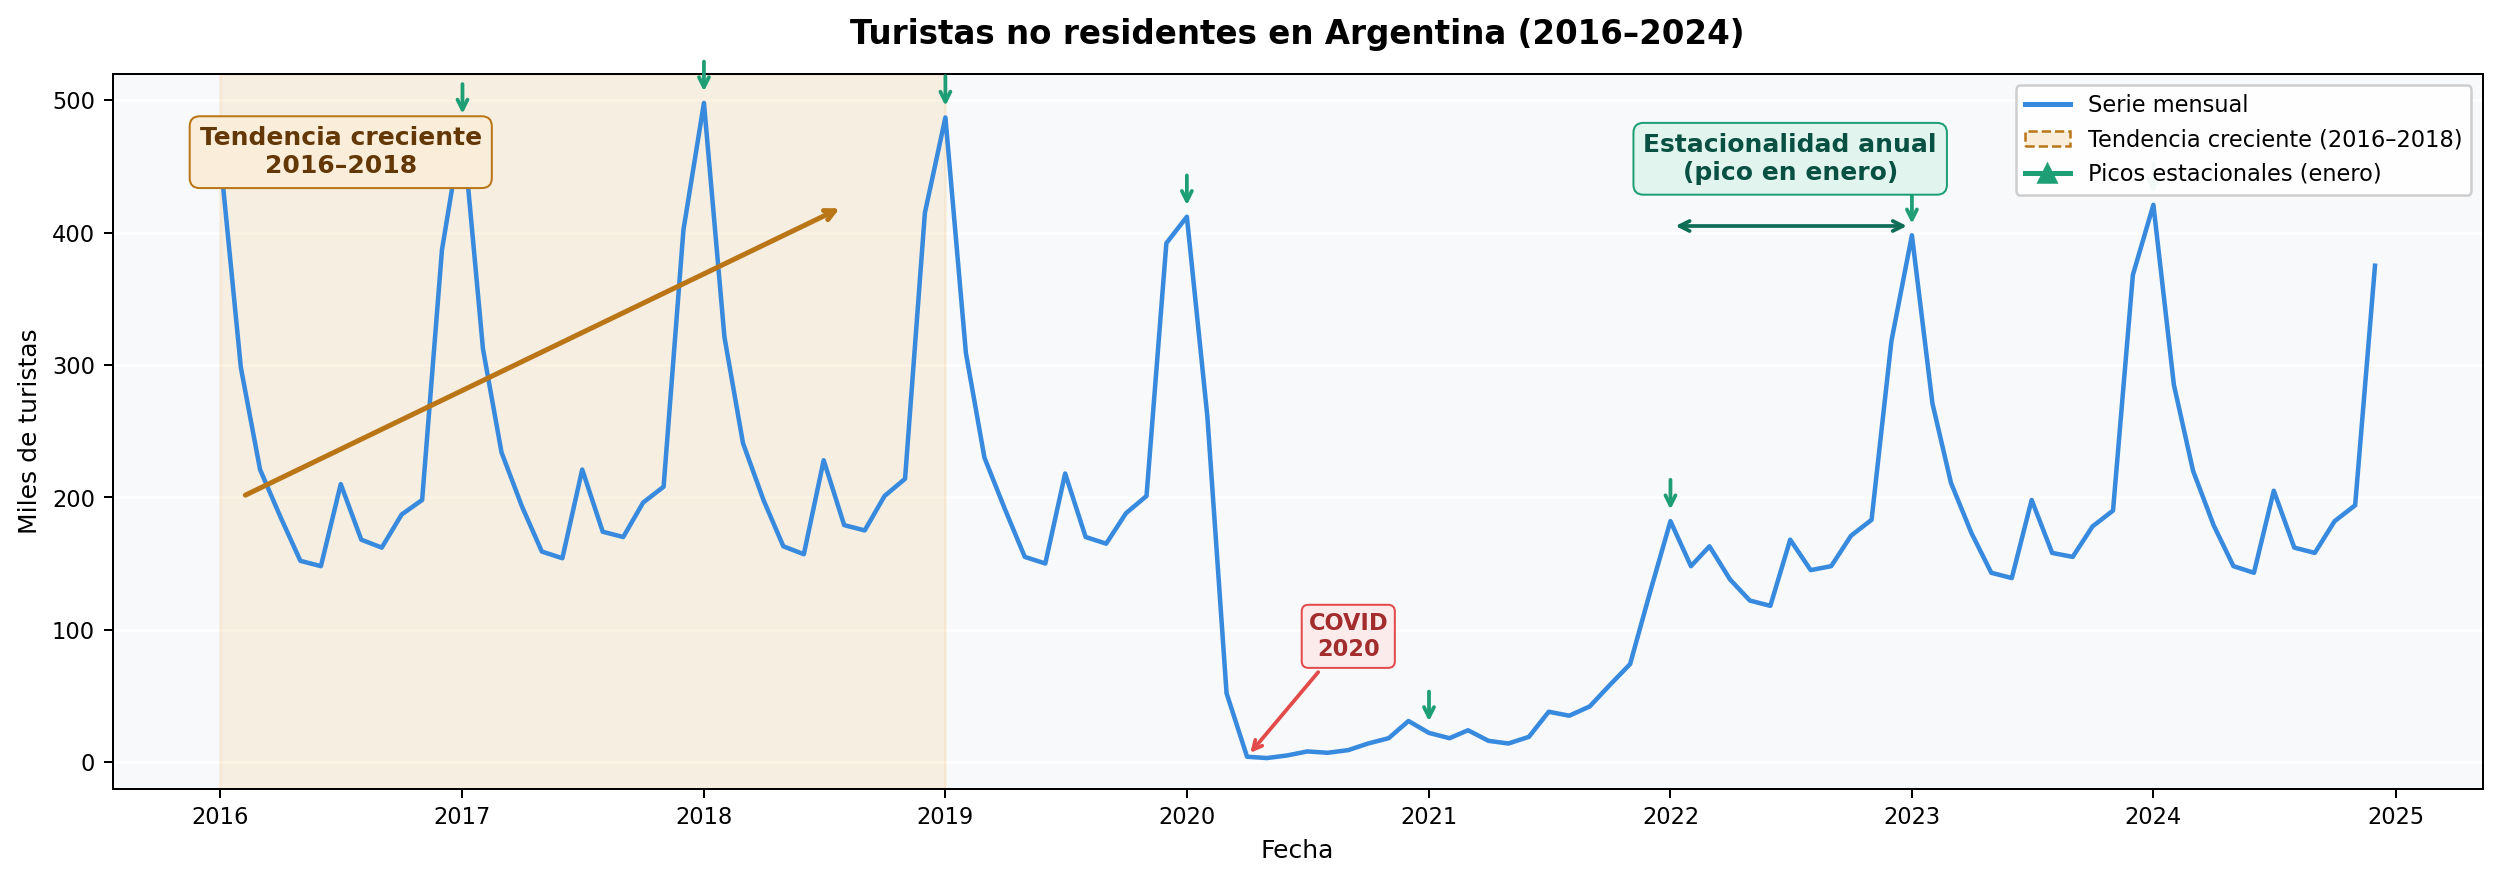

> **Para pensar:** ¿En qué meses se concentran los picos? ¿Qué evento explica la caída abrupta de 2020? ¿La serie se recuperó completamente?

---

## Parte 2: Acceder a componentes de la fecha con `.dt`

Una vez que el índice es un `DatetimeIndex`, podemos extraer partes de la fecha directamente.

In [6]:
# Acceder al año, mes y nombre del mes desde el índice
print(df.index.month[:5])   # primeros 5 meses

Index([1, 2, 3, 4, 5], dtype='int32', name='fecha')


In [7]:
print(df.index.month_name()[:5])  # nombre del mes

Index(['January', 'February', 'March', 'April', 'May'], dtype='object', name='fecha')


 ¿Cuál es el mes con más turistas en promedio (sobre toda la serie)?

In [8]:
#agrupa todas las observaciones por número de mes (todos los eneros, ferbreros ...de todos los años)
promedio_por_mes = df.groupby(df.index.month)['turistas_no_residentes_miles'].mean().round(1)
#reemplazamos el indice numerico por nombres de meses
promedio_por_mes.index = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']
#ordenamos
promedio_por_mes.sort_values(ascending=False)

,turistas_no_residentes_miles
Ene,373.0
Dic,312.9
Feb,247.0
Mar,177.3
Jul,166.0
Nov,164.4
Oct,152.8
Abr,141.9
Ago,133.1
Sep,131.6


> **Para pensar:** ¿Tiene sentido el patrón estacional que muestra esta tabla? ¿Por qué enero tiene tantos turistas?

---

## Parte 3: Resampling — cambiar la frecuencia de la serie

`resample()` es como un `groupby` pero para tiempo. Permite agrupar observaciones en períodos más largos (de mensual a trimestral, de mensual a anual, etc.).

**Códigos de frecuencia más usados:**

| Código | Frecuencia |
|--------|------------|
| `'ME'` | Fin de mes |
| `'QE'` | Fin de trimestre |
| `'YE'` | Fin de año |

### 3.1 Resample anual

Total de turistas por año

In [9]:
anual = df.resample('YE').sum()
anual.index = anual.index.year  # simplificar el índice para visualización
anual

,turistas_no_residentes_miles
fecha,
2016,2772
2017,2904
2018,2990
2019,2856
2020,824
2021,488
2022,2004
2023,2582
2024,2672


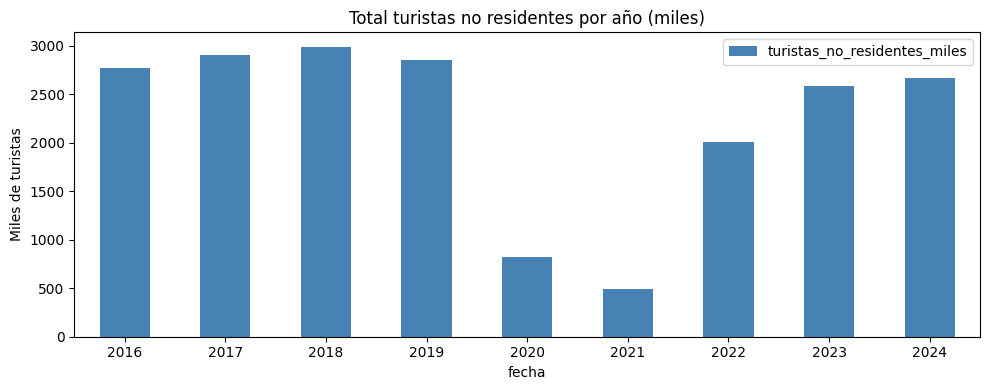

In [10]:
anual.plot(kind='bar', figsize=(10, 4), title='Total turistas no residentes por año (miles)', color='steelblue')
plt.ylabel('Miles de turistas')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 3.2 Resample trimestral

Promedio de turistas por trimestre

In [11]:
trimestral = df.resample('QE').mean().round(1)
trimestral.head(12)

,turistas_no_residentes_miles
fecha,
2016-03-31,325.0
2016-06-30,161.7
2016-09-30,180.0
2016-12-31,257.3
2017-03-31,342.3
2017-06-30,168.7
2017-09-30,188.3
2017-12-31,268.7
2018-03-31,353.3


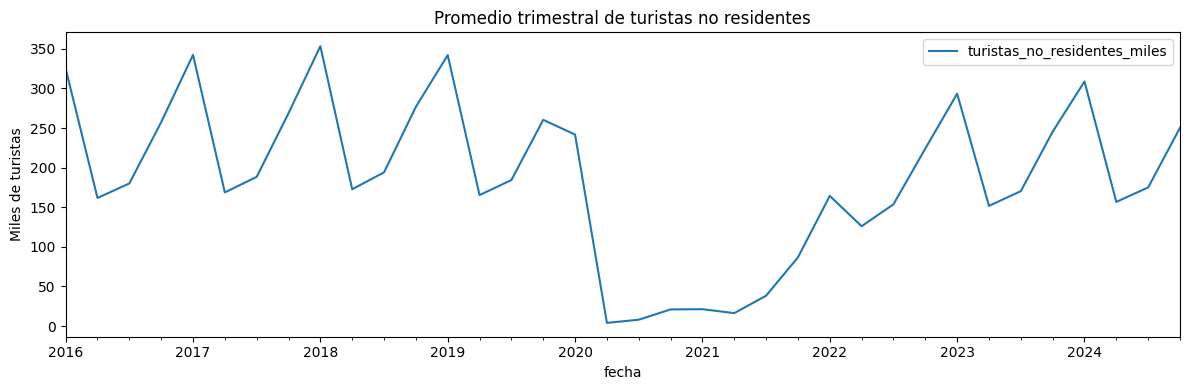

In [12]:
trimestral.plot(figsize=(12, 4), title='Promedio trimestral de turistas no residentes', ylabel='Miles de turistas')
plt.tight_layout()
plt.show()

> **Para pensar:** Al pasar de mensual a trimestral, ¿se pierde o se gana algo? ¿Qué información desaparece?

---

## Parte 4: Rolling — promedio móvil

`rolling(window=N)` calcula una estadística sobre una ventana deslizante de N períodos. Es útil para **suavizar** series ruidosas y hacer más visible la tendencia.

A diferencia de `resample`, **no cambia la cantidad de filas**: mantiene un punto por cada observación original.

### 4.1 Comparar serie original vs. promedio móvil de 12 meses

Calcular el promedio móvil de 12 meses

In [13]:

df['promedio_movil_12m'] = df['turistas_no_residentes_miles'].rolling(window=12).mean()

df.head(15)  # los primeros 11 valores del promedio móvil van a ser NaN — ¿por qué?

,turistas_no_residentes_miles,promedio_movil_12m
fecha,,
2016-01-01,456,NaN
2016-02-01,298,NaN
2016-03-01,221,NaN
2016-04-01,185,NaN
2016-05-01,152,NaN
2016-06-01,148,NaN
2016-07-01,210,NaN
2016-08-01,168,NaN
2016-09-01,162,NaN


Los primeros 11 meses de 2016 van a ser NaN. No es un error — es que todavía no hay 12 meses de historia para calcular el promedio. El primer valor válido aparece en diciembre de 2016.

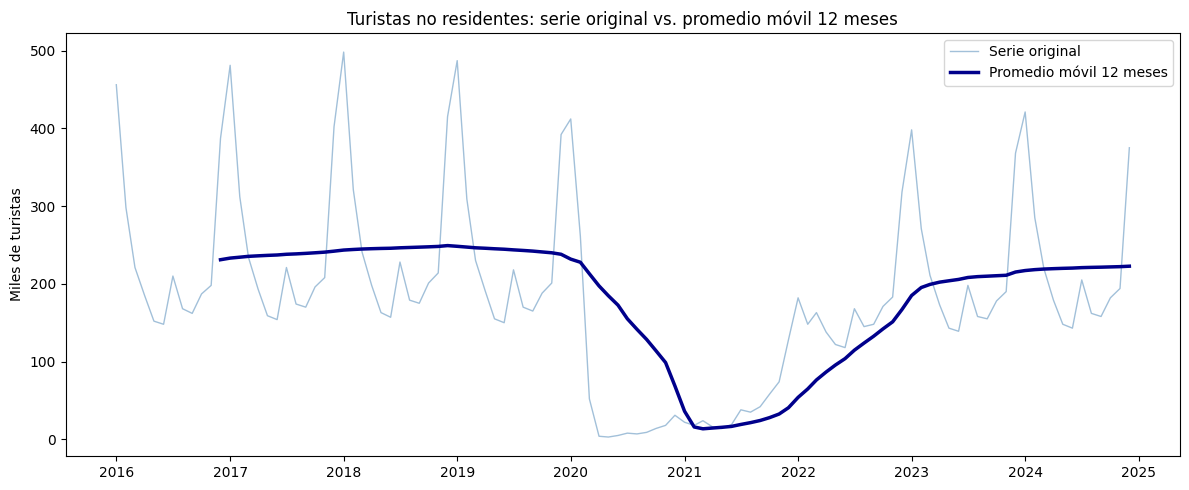

In [14]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(df.index, df['turistas_no_residentes_miles'],
        label='Serie original', color='steelblue', alpha=0.5, linewidth=1)
ax.plot(df.index, df['promedio_movil_12m'],
        label='Promedio móvil 12 meses', color='darkblue', linewidth=2.5)

ax.set_title('Turistas no residentes: serie original vs. promedio móvil 12 meses')
ax.set_ylabel('Miles de turistas')
ax.legend()
plt.tight_layout()
plt.show()

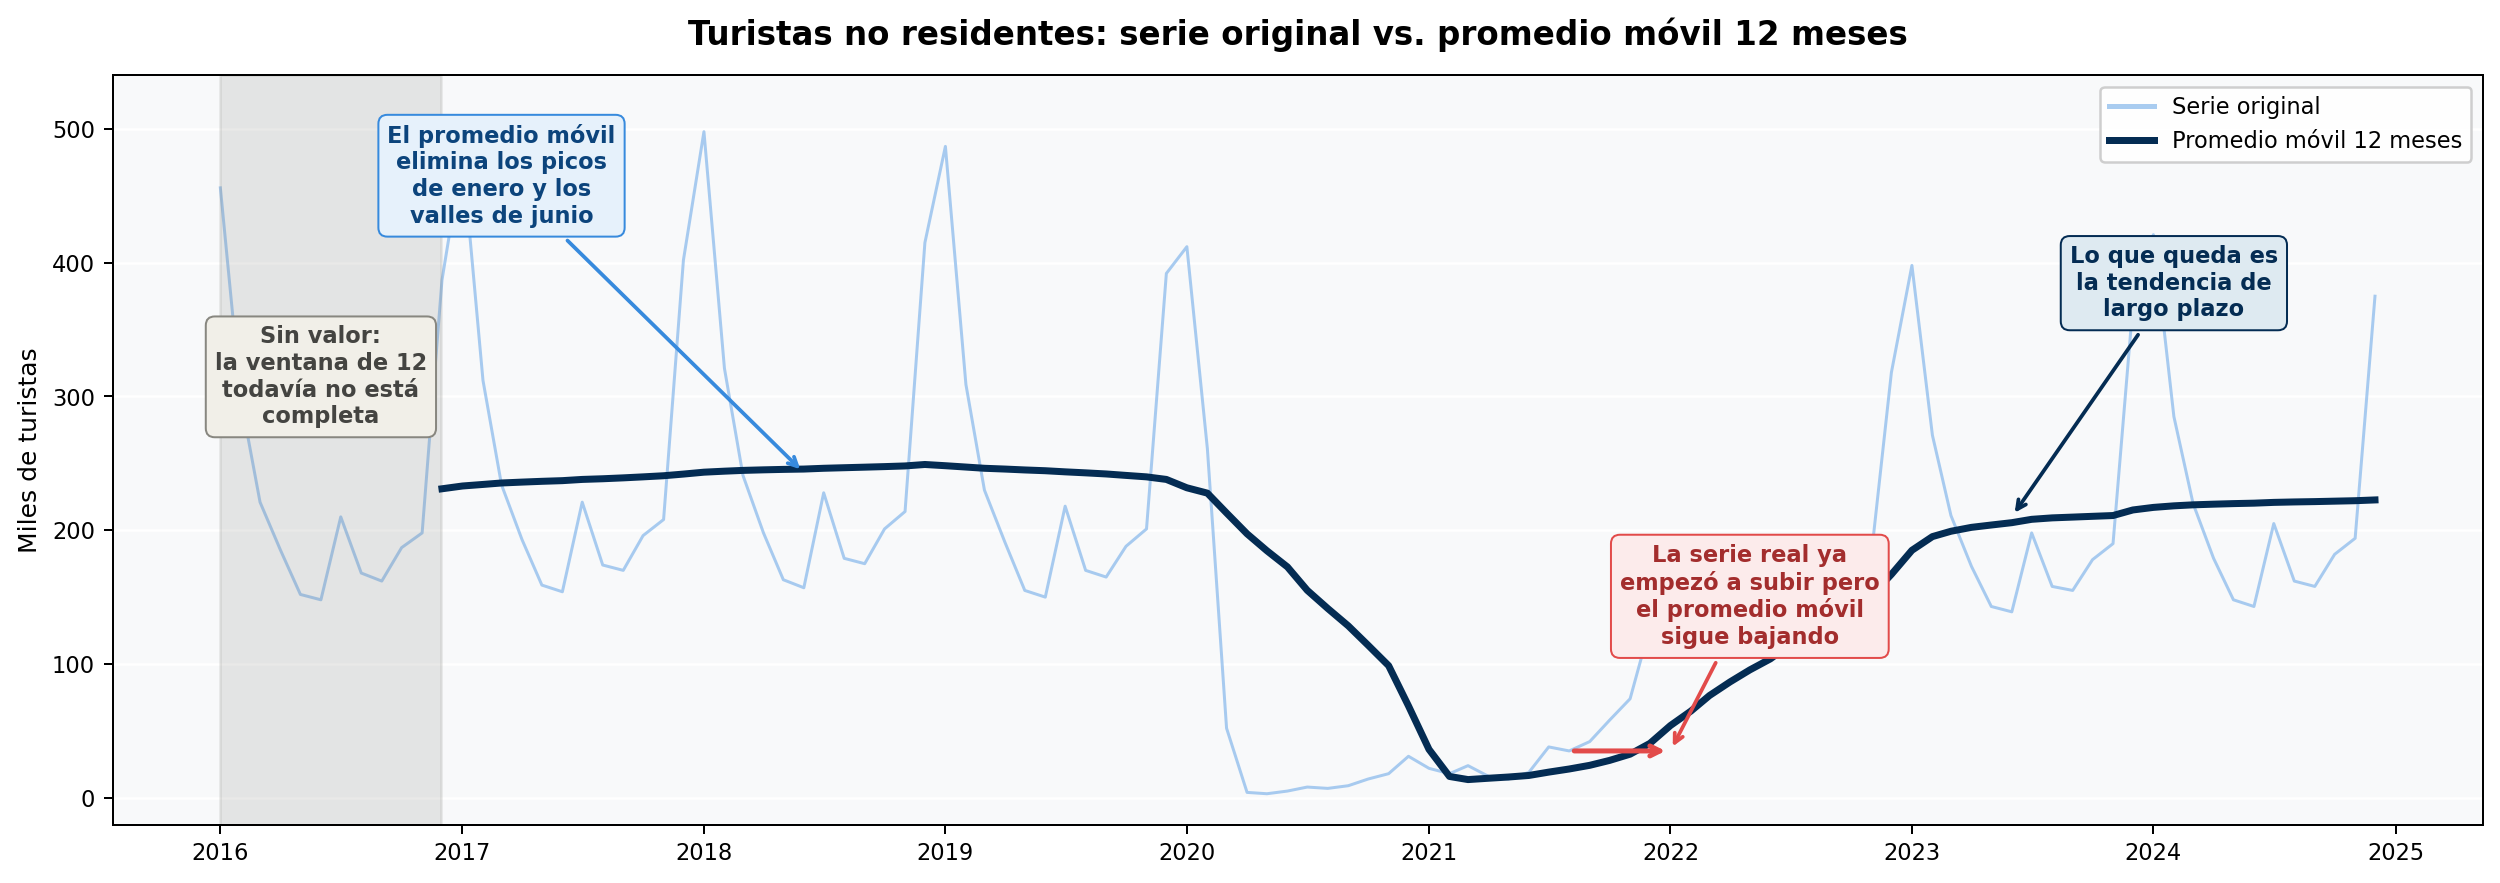

### 4.2 Explorar el efecto del tamaño de ventana

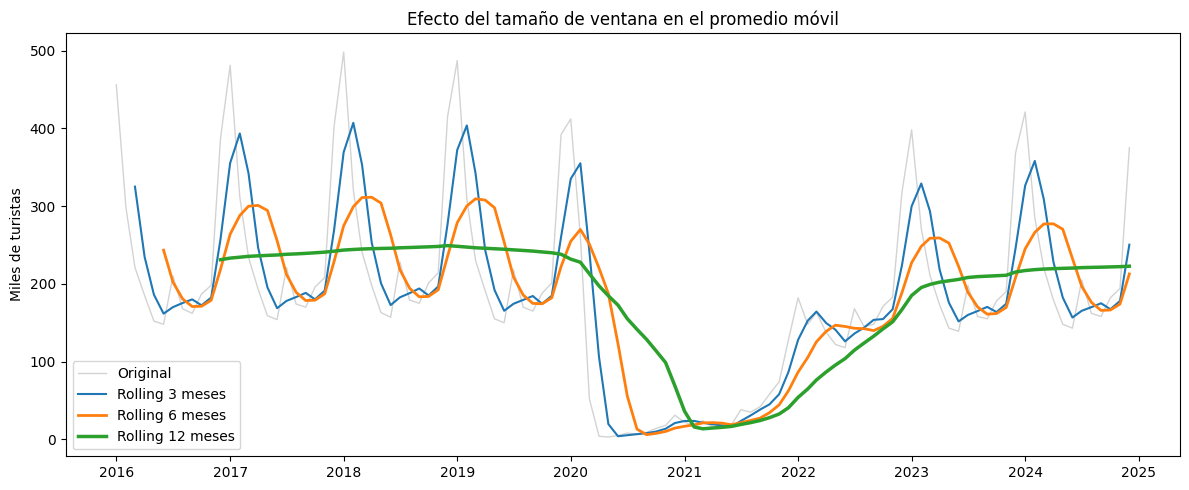

In [15]:
# Calcular promedio móvil de 3, 6 y 12 meses
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(df.index, df['turistas_no_residentes_miles'],
        label='Original', color='lightgray', linewidth=1)
ax.plot(df.index, df['turistas_no_residentes_miles'].rolling(3).mean(),
        label='Rolling 3 meses', linewidth=1.5)
ax.plot(df.index, df['turistas_no_residentes_miles'].rolling(6).mean(),
        label='Rolling 6 meses', linewidth=2)
ax.plot(df.index, df['turistas_no_residentes_miles'].rolling(12).mean(),
        label='Rolling 12 meses', linewidth=2.5)

ax.set_title('Efecto del tamaño de ventana en el promedio móvil')
ax.set_ylabel('Miles de turistas')
ax.legend()
plt.tight_layout()
plt.show()

### 4.3 Media móvil exponencial *(Exponentially Weighted Moving Average, EWMA)*

`ewm()` es similar a `rolling()` pero da **más peso a los datos recientes**. No genera `NaN` iniciales porque puede calcularse desde el primer punto.

El parámetro `span` es equivalente a la ventana N de la SMA: `span=12` da un suavizado similar a `window=12`, pero reacciona más rápido a cambios recientes.

In [16]:
# Calcular EWMA con span equivalente al rolling de 12
df['ewma_12'] = df['turistas_no_residentes_miles'].ewm(span=12).mean()

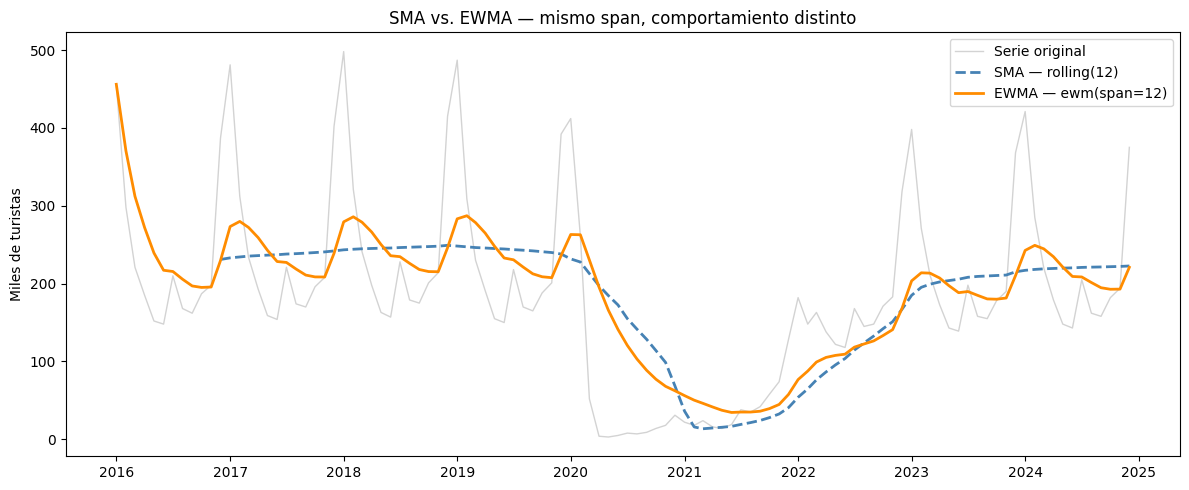

In [17]:
# Comparar: serie original, SMA 12 meses y EWMA span 12
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(df.index, df['turistas_no_residentes_miles'],
        label='Serie original', color='lightgray', linewidth=1)
ax.plot(df.index, df['promedio_movil_12m'],
        label='SMA — rolling(12)', color='steelblue', linewidth=2, linestyle='--')
ax.plot(df.index, df['ewma_12'],
        label='EWMA — ewm(span=12)', color='darkorange', linewidth=2)

ax.set_title('SMA vs. EWMA — mismo span, comportamiento distinto')
ax.set_ylabel('Miles de turistas')
ax.legend()
plt.tight_layout()
plt.show()

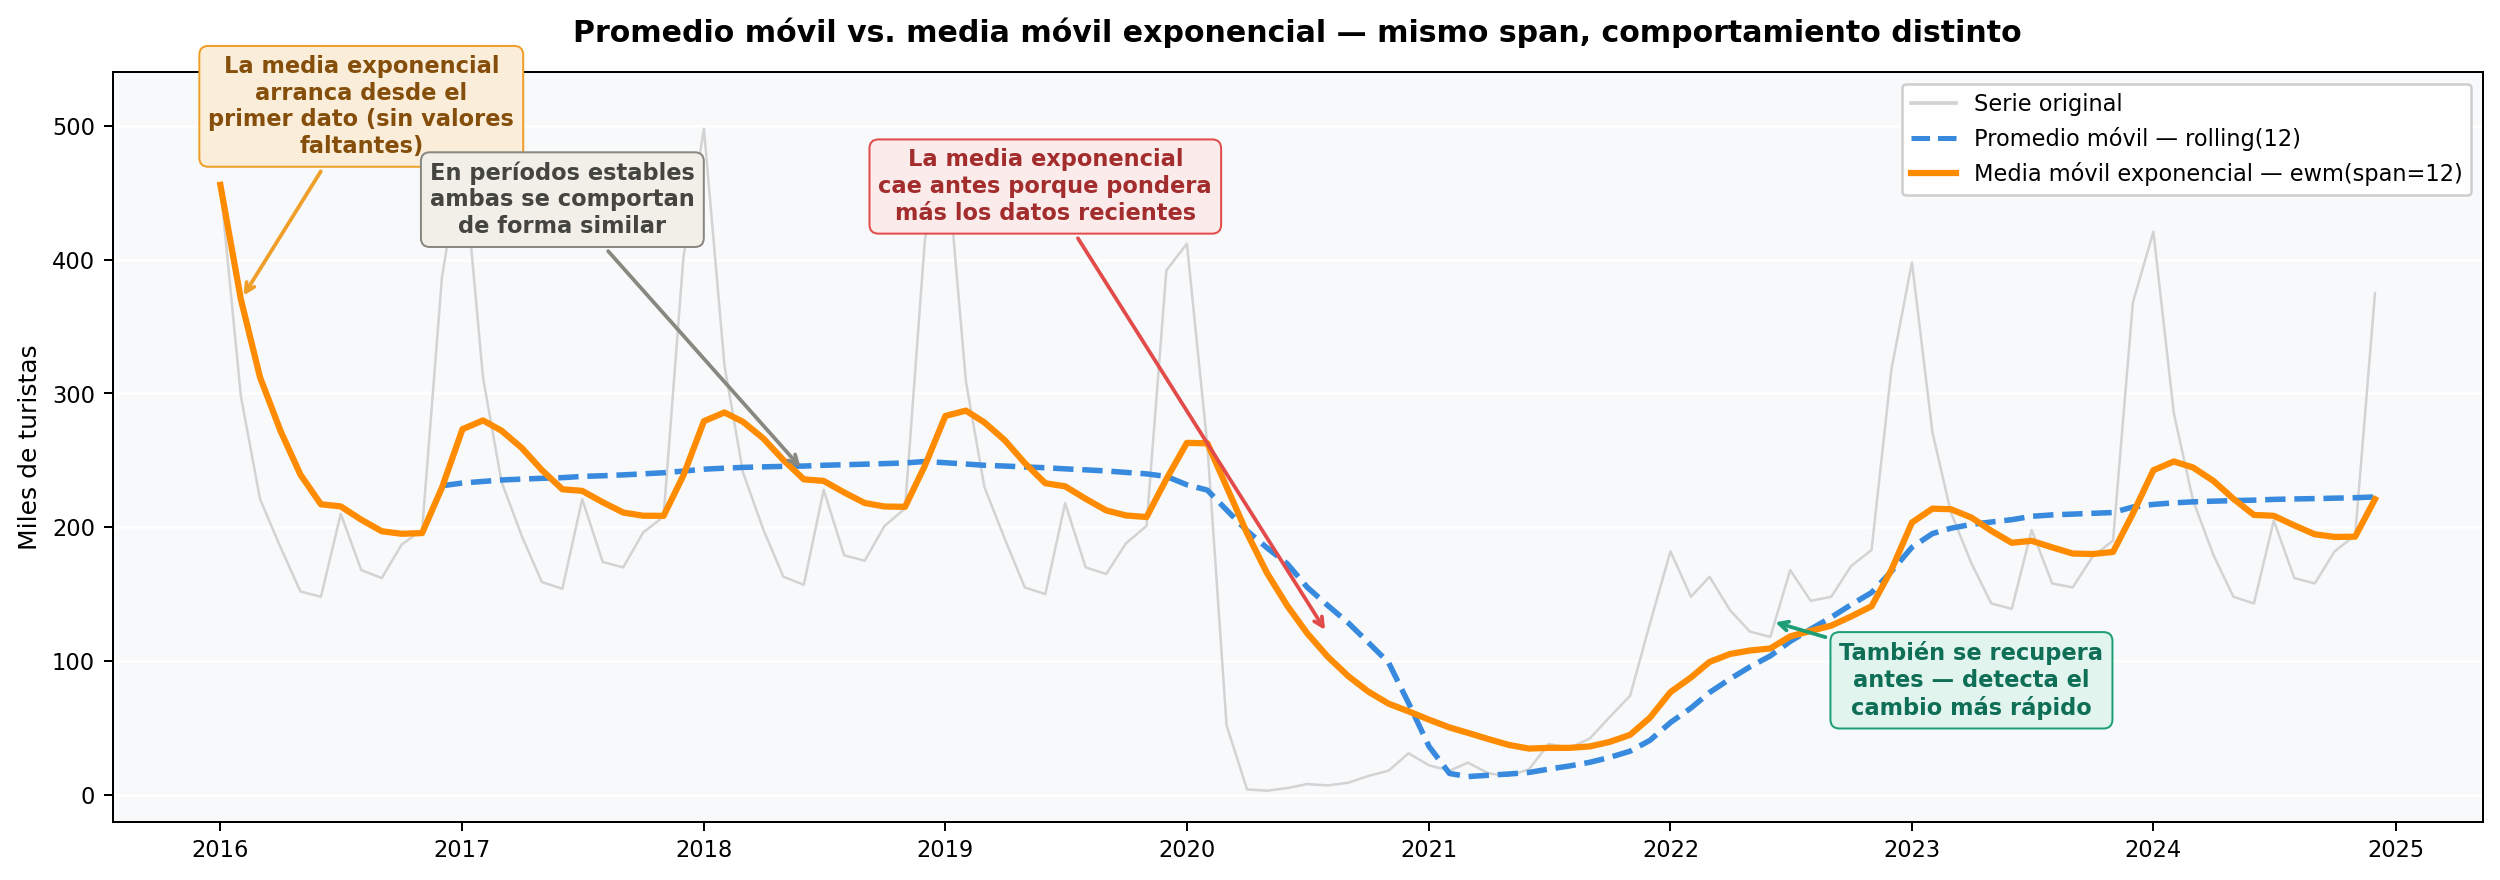